# 3次元の丸線からCLNを得る：A–φ・T–Ω・A–T

谷本氏の学生ノートをもとに、3つの定式化をNGSolveで再現します。未知量は異なりますが、比較するのは復元した電界・磁束密度と、エネルギーから得る同じ順序の回路定数です。

**検証範囲は、円柱導体内部、線形材料、展開点 $s_0=0$、$R_0,L_1,R_2$ です。** 外部空気領域、戻り導体、非零展開点、高次段、多連結領域は含みません。独立したClaudeレビューは復帰後に行います。本ノートの図表は保存済みの実行結果を読み込んで検査します。FEMの再計算は最後の手順で行えます。

## 最初に、規格化をそろえる

半径 $a=0.01$ m、長さ $h=0.01$ m、導電率 $\sigma=10^6$ S/m、透磁率 $\mu=4\pi 10^{-7}$ H/m。初期電界は軸方向の $1$ V/m で、端子間電圧は $h$ V です。この座標で算出する係数は

$$R_0=\frac{1}{\pi a^2\sigma h},\qquad L_1=\frac{\mu}{8\pi h},\qquad R_2=3R_0.$$

端子電圧1 Vを基準とする回路では、各係数に $h^2$ を掛けます。したがって、保存された数値をそのまま端子回路のΩ・Hと読んではいけません。磁気エネルギーは導体内部だけの値です。

## 境界条件とゲージの役割

A–φでは端面のφに電圧を与え、Aの接線成分を表面で拘束します。T–ΩとA–Tでは側面に初期電界の境界源を与えます。Ωは自然境界条件です。定式化ごとのこの設計を保持しています。

curl–curl行列には勾配の零空間が残ります。右辺を零空間と直交させることと、行列を非特異にすることは別の操作です。ここでは離散勾配行列 $G$ を用いて

$$A_g=A+\alpha GG^T,\qquad \alpha>0$$

をICCGで解きます。自由自由度上で $AG\simeq0$ を検査し、**元の行列Aに対する残差**を評価します。右辺射影の大きさと、射影前の右辺に対する残差も別々に保存します。射影は荷重の変更であり、ゲージ不変性だけで正当化できません。除去割合が $10^{-4}$ を超える場合は計算を停止します。

A–φ・T–Ωのスカラー空間にはベクトル空間より1つ高い次数を使用します。これは勾配による場の復元を表現するためです。ICCGのshiftは据え置きで、ゲージの係数αとは別です。

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
root=Path.cwd()
if not (root/'validation').is_dir():
    root=root.parent
record=json.loads((root/'docs/data/three_dimensional.json').read_text(encoding='utf-8'))
cases=record['cases']
print(record['scope'])
print('formulation   mesh h [m]    R0 error[%]    L1 error[%]    R2 error[%]')
for c in cases:
    print(f"{c['formulation']:11}   {c['maxh']:.4f}        " + '   '.join(f'{100*x:10.5f}' for x in c['relative_errors']))
for c in cases:
    for info in c['result']['solves']:
        assert info['explicit_residual'] <= 1e-7
        assert info['original_rhs_residual'] <= 1.001e-4
print('Residual checks passed')


3D cylinder, internal energy, s0=0, order=1, R0/L1/R2
formulation   mesh h [m]    R0 error[%]    L1 error[%]    R2 error[%]
A-phi         0.0030           0.00065      2.04565      4.85810
A-phi         0.0010           0.00001      0.24872      0.66973
T-Omega       0.0030           0.22030      0.11346     17.51355
T-Omega       0.0010           0.00788      0.00443      2.07238
A-T           0.0030           0.22030      2.15970     12.17427
A-T           0.0010           0.00788      0.25321      1.39252
Residual checks passed


## 回路定数と物理場の収束を分けて見る

同じ積分値だけでは、場まで一致したとは言えません。そこで円柱の中央断面の25点で、電界と磁束密度の3成分を解析式と比較します。

初期場は $E_{0,z}=1$、第1磁場は $B_{1,\theta}=\mu R_0\sigma r/2$、次の電界は $E_{2,z}=2(r/a)^2-1$ です。図には軸方向電界を描きますが、誤差の検査は横成分も含むベクトル全体で行います。点列のRMS誤差は体積ノルムとは異なります。

A-phi finest field RMS: {'E0': 3.0014311477940157e-06, 'B1': 0.04479790168336276, 'E2': 0.0042843625747779335}
T-Omega finest field RMS: {'E0': 0.00037360633564504405, 'B1': 8.106771602481174e-05, 'E2': 0.07879474072727544}
A-T finest field RMS: {'E0': 0.0003736063348055812, 'B1': 0.044786520786804195, 'E2': 0.07884791520735616}


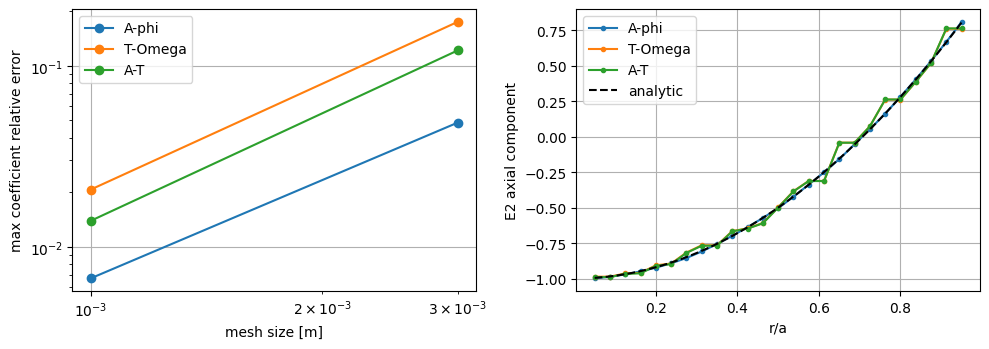

In [2]:
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for name in ['A-phi','T-Omega','A-T']:
    rows=[c for c in cases if c['formulation']==name]
    coarse,fine=rows
    assert all(a>2.5*b for a,b in zip(coarse['relative_errors'],fine['relative_errors']))
    axes[0].loglog([c['maxh'] for c in rows],[max(c['relative_errors']) for c in rows],'o-',label=name)
    p=fine['result']['field_profiles']
    axes[1].plot(p['rho'],np.asarray(p['E2'])[:,2],'.-',label=name)
    print(name,'finest field RMS:',fine['field_relative_rms'])
rho=np.linspace(.05,.95,150)
axes[1].plot(rho,2*rho**2-1,'k--',label='analytic')
axes[0].set(xlabel='mesh size [m]',ylabel='max coefficient relative error')
axes[1].set(xlabel='r/a',ylabel='E2 axial component')
for ax in axes:
    ax.grid(True); ax.legend()
plt.tight_layout(); plt.show()


## ゲージ項を変えても同じ回路か

同一メッシュでゲージ項の重みを0.1、1、10と変え、回路定数を比較しました。これはICCGの加速係数shiftを変える試験ではありません。回路定数は安定しましたが、反復回数は大きく変わりました。強いゲージ項ほど良いとは限りません。

この試験では3つの回路定数に加え、同じ25点の電界・磁束密度も比較しています。任意の形状・次数・段数の保証には拡張しません。

In [3]:
gauge=json.loads((root/'docs/data/three_dimensional_gauge.json').read_text(encoding='utf-8'))
for name,item in gauge.items():
    change=item['max_relative_gauge_change']
    assert change < 1e-7
    print(name, 'max relative circuit change:',f'{change:.3e}')
    assert max(item['max_relative_field_change'].values()) < 1e-7
    print('  physical field changes:',item['max_relative_field_change'])
    print('  weights / ICCG iterations:',[(r['weight'],[s['iterations'] for s in r['solves']]) for r in item['runs']])
# R and L in terminal coordinates for this cylinder.
fine=next(c for c in cases if c['formulation']=='A-phi' and c['maxh']==min(x['maxh'] for x in cases))
h=fine['result']['params']['h']
print('A-phi terminal [R0,L1,R2]:',np.asarray(fine['coefficients'])*h**2)


CLN_APhi max relative circuit change: 4.683e-13
  physical field changes: {'E0': 1.1632706063791207e-15, 'B1': 4.321145179349943e-11, 'E2': 2.9163969235544936e-11}
  weights / ICCG iterations: [(0.1, [23, 20, 23]), (1.0, [23, 27, 23]), (10.0, [23, 51, 23])]
CLN_T_Omega max relative circuit change: 1.288e-11
  physical field changes: {'E0': 4.671663734712239e-11, 'B1': 1.7730325549635193e-11, 'E2': 7.821631056987732e-11}
  weights / ICCG iterations: [(0.1, [24, 25, 23]), (1.0, [46, 25, 46]), (10.0, [3036, 25, 2408])]
CLN_AT max relative circuit change: 6.275e-12
  physical field changes: {'E0': 3.015450152833779e-11, 'B1': 3.9831939554487044e-11, 'E2': 7.055702985035689e-11}
  weights / ICCG iterations: [(0.1, [24, 20, 23]), (1.0, [46, 27, 46]), (10.0, [2009, 51, 2543])]
A-phi terminal [R0,L1,R2]: [3.18309865e-05 4.98756406e-10 9.48534180e-05]


## 再実行と自己レビューの範囲

公開コードは [validation/validate_3d.py](../validation/validate_3d.py) と [3つの定式化](../validation/cln3d/) にあります。NGSolve・numpy・scipy・公開Radiaパッケージを同じPython環境に入れて、リポジトリ直下から実行します。

```text
python validation/validate_3d.py --output three_dimensional.json
python validation/cln3d/verify_gauge.py
```

1つ目は3定式化×2メッシュを再計算し、正のエネルギー、元のcurl–curl行列に対する残差、メッシュ細分化による改善、解析場との比較を検査します。2つ目はゲージ重みの感度を確認します。出力は作業ディレクトリに保存します。

自己レビューでは、GridFunctionを各solveで新規作成すること、境界リフティングを保つこと、右辺射影量を隠さないこと、規格化を端子値と区別することを確認しました。学生ノートの履歴は変更していません。

今回の有限メッシュで3つの定式化は完全一致していません。誤差を減らす方向での一致を確認した再現例です。非零展開点の証明は [Type1](type1_same_circuit.ipynb)・[Type2](type2_same_circuit.ipynb) を参照してください。ここでの3次元計算を、その証明の3次元版とは扱いません。
